# Validation des modèles (dossier models/)

Ce notebook charge les modèles entraînés présents dans `models/`, les évalue sur **le même jeu de test**, puis détermine automatiquement le meilleur modèle selon le **F1-score** (prioritaire en contexte de classes déséquilibrées).

In [6]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

In [7]:
DATA_PATH = 'AI4BMI_predictive_maintenance_dataset.csv'
MODELS_DIR = 'models'
TARGET_COL = 'failure_next_24h'

assert os.path.exists(DATA_PATH), f'Dataset introuvable: {DATA_PATH}'
assert os.path.isdir(MODELS_DIR), f'Dossier introuvable: {MODELS_DIR}'

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=[TARGET_COL]).copy()

# Encodage cohérent avec les notebooks existants
if 'machine_type' in df.columns and 'machine_type_encoded' not in df.columns:
    le = LabelEncoder()
    df['machine_type_encoded'] = le.fit_transform(df['machine_type'].astype(str))

# Features temporelles si une colonne de timestamp/date existe
time_candidates = ['timestamp', 'datetime', 'date', 'event_time']
time_col = next((c for c in time_candidates if c in df.columns), None)
if time_col is not None:
    dt = pd.to_datetime(df[time_col], errors='coerce')
    if 'hour' not in df.columns:
        df['hour'] = dt.dt.hour
    if 'day_of_week' not in df.columns:
        df['day_of_week'] = dt.dt.dayofweek
    if 'is_weekend' not in df.columns:
        df['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)

df = df.dropna().reset_index(drop=True)

y = df[TARGET_COL].astype(int).values
X_df = df.drop(columns=[TARGET_COL]).copy()

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data shape (après nettoyage): {df.shape}')
print(f'Train size: {len(X_train_df)} | Test size: {len(X_test_df)}')
print('Colonnes disponibles:', len(X_df.columns))

Data shape (après nettoyage): (200000, 19)
Train size: 160000 | Test size: 40000
Colonnes disponibles: 18


In [14]:
def list_model_files(models_dir='models'):
    pkl_files = sorted([f for f in os.listdir(models_dir) if f.endswith('.pkl')])
    json_files = sorted([f for f in os.listdir(models_dir) if f.endswith('_metadata.json')])
    return pkl_files, json_files


def load_json(path):
    if not os.path.exists(path):
        return {}
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def load_model_artifact(path):
    try:
        with open(path, 'rb') as f:
            return pickle.load(f)
    except Exception:
        import joblib
        return joblib.load(path)


def extract_predictor(obj):
    if obj is None:
        return None

    if hasattr(obj, 'predict'):
        return obj

    if isinstance(obj, dict):
        for v in obj.values():
            cand = extract_predictor(v)
            if cand is not None:
                return cand
        return None

    if isinstance(obj, (list, tuple)):
        for v in obj:
            cand = extract_predictor(v)
            if cand is not None:
                return cand
        return None

    if isinstance(obj, np.ndarray):
        for v in obj.ravel().tolist():
            cand = extract_predictor(v)
            if cand is not None:
                return cand
        return None

    return None


def detect_threshold(metadata):
    for k in ['selected_threshold_f1', 'best_threshold', 'threshold']:
        v = metadata.get(k)
        if isinstance(v, (int, float)):
            return float(v)

    candidates = [
        metadata.get('metrics_tuned', {}),
        metadata.get('scores_tuned_threshold', {}),
        metadata.get('scores_default_threshold_0_5', {})
    ]
    for section in candidates:
        v = section.get('best_threshold', section.get('threshold')) if isinstance(section, dict) else None
        if isinstance(v, (int, float)):
            return float(v)

    return 0.5


def candidate_feature_lists(metadata, x_columns, model=None, model_name=''):
    x_columns = list(x_columns)
    candidates = []

    # Jeux de features connus dans ce projet
    base_12 = [
        'maintenance_age_days', 'vib_mean', 'vib_std', 'vib_rms',
        'temp_mean', 'temp_max', 'current_mean', 'current_peak',
        'acoustic_energy', 'rpm_mean', 'oil_particle_count'
    ]
    set_12_encoded = [c for c in base_12 if c in x_columns] + (['machine_type_encoded'] if 'machine_type_encoded' in x_columns else [])
    set_12_raw = (['machine_type'] if 'machine_type' in x_columns else []) + [c for c in base_12 if c in x_columns]
    set_15 = set_12_raw + [c for c in ['hour', 'day_of_week', 'is_weekend'] if c in x_columns]

    # 1) Features metadata exactes
    meta_feats = metadata.get('features', []) if isinstance(metadata, dict) else []
    if meta_feats:
        exact = [c for c in meta_feats if c in x_columns]
        if exact:
            candidates.append(exact)

        # Variante encodée pour machine_type
        encoded_variant = []
        for c in meta_feats:
            if c == 'machine_type' and 'machine_type_encoded' in x_columns:
                encoded_variant.append('machine_type_encoded')
            elif c in x_columns:
                encoded_variant.append(c)
        if encoded_variant:
            candidates.append(encoded_variant)

    # 2) Priorités par nom de modèle
    lower_name = str(model_name).lower()
    if 'random_forest' in lower_name or 'randomforest' in lower_name:
        if set_12_encoded:
            candidates.append(set_12_encoded)
    if 'lgbm' in lower_name or 'lightgbm' in lower_name:
        if set_12_raw:
            candidates.append(set_12_raw)
        if set_12_encoded:
            candidates.append(set_12_encoded)
    if 'logistic' in lower_name:
        if set_15:
            candidates.append(set_15)

    # 3) Guidage par n_features_in_
    nfi = getattr(model, 'n_features_in_', None) if model is not None else None
    if isinstance(nfi, (int, np.integer)):
        for known in [set_12_encoded, set_12_raw, set_15]:
            if len(known) == int(nfi):
                candidates.append(known)

    # 4) fallback numériques
    numeric_cols = X_test_df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        candidates.append(numeric_cols)

    unique_lists = []
    seen = set()
    for cols in candidates:
        cols = [c for c in cols if c in x_columns]
        key = tuple(cols)
        if key and key not in seen:
            seen.add(key)
            unique_lists.append(cols)
    return unique_lists


def safe_predict(model, X):
    y_pred = model.predict(X)
    y_prob = None
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        if isinstance(proba, np.ndarray) and proba.ndim == 2 and proba.shape[1] >= 2:
            y_prob = proba[:, 1]
    return y_pred, y_prob


def compute_metrics(y_true, y_pred, y_prob=None):
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }
    if y_prob is not None:
        try:
            out['roc_auc'] = roc_auc_score(y_true, y_prob)
        except Exception:
            out['roc_auc'] = np.nan
        try:
            out['pr_auc'] = average_precision_score(y_true, y_prob)
        except Exception:
            out['pr_auc'] = np.nan
    else:
        out['roc_auc'] = np.nan
        out['pr_auc'] = np.nan
    return out

In [12]:
pkl_files, json_files = list_model_files(MODELS_DIR)
print('Modèles détectés:', pkl_files)
print('Métadonnées détectées:', json_files)

Modèles détectés: ['lgbm_pipeline.pkl', 'logistic_regression_balanced.pkl', 'random_forest_smote_pipeline.pkl']
Métadonnées détectées: ['lgbm_pipeline_metadata.json', 'logistic_regression_balanced_metadata.json', 'randomforest_balanced_metadata.json']


In [15]:
results = []
errors = []

for pkl_name in pkl_files:
    model_path = os.path.join(MODELS_DIR, pkl_name)

    # heuristique de matching metadata
    stem = pkl_name.replace('.pkl', '')
    metadata_candidates = [
        f'{stem}_metadata.json',
        'randomforest_balanced_metadata.json' if 'random_forest' in stem else None,
        'logistic_regression_balanced_metadata.json' if 'logistic' in stem else None,
        'lgbm_pipeline_metadata.json' if 'lgbm' in stem else None
    ]
    metadata_candidates = [m for m in metadata_candidates if m is not None]

    metadata = {}
    for candidate in metadata_candidates:
        candidate_path = os.path.join(MODELS_DIR, candidate)
        if os.path.exists(candidate_path):
            metadata = load_json(candidate_path)
            break

    try:
        artifact = load_model_artifact(model_path)
        model = extract_predictor(artifact)

        # Fallback: si artefact non exploitable, on garde au moins les scores metadata
        if model is None:
            tuned = metadata.get('scores_tuned_threshold', metadata.get('metrics_tuned', {}))
            default = metadata.get('scores_default_threshold_0_5', metadata.get('metrics_default', {}))
            if tuned or default:
                results.append({
                    'model_file': pkl_name,
                    'model_label': metadata.get('selected_model_name', metadata.get('model_name', stem)),
                    'n_features_used': len(metadata.get('features', [])),
                    'threshold_used': detect_threshold(metadata),
                    'accuracy_default': default.get('accuracy', np.nan),
                    'precision_default': default.get('precision', np.nan),
                    'recall_default': default.get('recall', np.nan),
                    'f1_default': default.get('f1', np.nan),
                    'roc_auc': default.get('roc_auc', tuned.get('roc_auc', np.nan)),
                    'pr_auc': default.get('pr_auc', tuned.get('pr_auc', np.nan)),
                    'accuracy_tuned': tuned.get('accuracy', np.nan),
                    'precision_tuned': tuned.get('precision', np.nan),
                    'recall_tuned': tuned.get('recall', np.nan),
                    'f1_tuned': tuned.get('f1', np.nan),
                    'confusion_matrix_tuned': None,
                    'evaluation_source': 'metadata_only'
                })
                continue
            raise RuntimeError(f'Aucun estimateur trouvable dans l\'artefact de type {type(artifact)}')

        threshold = detect_threshold(metadata)
        tested = False
        last_error = None

        for cols in candidate_feature_lists(metadata, X_test_df.columns, model=model, model_name=stem):
            X_try = X_test_df[cols].copy()

            variants = [X_try]
            obj_cols = X_try.select_dtypes(include=['object']).columns.tolist()
            if obj_cols:
                X_conv = X_try.copy()
                for c in obj_cols:
                    if f'{c}_encoded' in X_test_df.columns:
                        X_conv[c] = X_test_df[f'{c}_encoded']
                    else:
                        X_conv[c] = pd.factorize(X_conv[c])[0]
                variants.append(X_conv)

            for X_variant in variants:
                try:
                    y_pred_default, y_prob = safe_predict(model, X_variant)
                    default_metrics = compute_metrics(y_test, y_pred_default, y_prob)

                    if y_prob is not None:
                        y_pred_tuned = (y_prob >= threshold).astype(int)
                        tuned_metrics = compute_metrics(y_test, y_pred_tuned, y_prob)
                    else:
                        y_pred_tuned = y_pred_default
                        tuned_metrics = default_metrics.copy()

                    results.append({
                        'model_file': pkl_name,
                        'model_label': metadata.get('selected_model_name', metadata.get('model_name', stem)),
                        'n_features_used': len(cols),
                        'threshold_used': threshold,
                        'accuracy_default': default_metrics['accuracy'],
                        'precision_default': default_metrics['precision'],
                        'recall_default': default_metrics['recall'],
                        'f1_default': default_metrics['f1'],
                        'roc_auc': default_metrics['roc_auc'],
                        'pr_auc': default_metrics['pr_auc'],
                        'accuracy_tuned': tuned_metrics['accuracy'],
                        'precision_tuned': tuned_metrics['precision'],
                        'recall_tuned': tuned_metrics['recall'],
                        'f1_tuned': tuned_metrics['f1'],
                        'confusion_matrix_tuned': confusion_matrix(y_test, y_pred_tuned).tolist(),
                        'evaluation_source': 'inference'
                    })

                    tested = True
                    break
                except Exception as e_inner:
                    last_error = str(e_inner)

            if tested:
                break

        if not tested:
            raise RuntimeError(last_error or 'Aucune combinaison de features compatible')

    except Exception as e:
        errors.append({'model_file': pkl_name, 'error': str(e)})

results_df = pd.DataFrame(results)
if not results_df.empty and 'f1_tuned' in results_df.columns:
    results_df = results_df.sort_values(by='f1_tuned', ascending=False).reset_index(drop=True)
    display(results_df)
else:
    print('Aucun résultat valide pour les modèles.')
    display(pd.DataFrame(results))

if errors:
    print('\nErreurs sur certains modèles:')
    display(pd.DataFrame(errors))

  File "c:\Users\PC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\PC\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PC\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PC\anaconda3\Lib\subprocess.py", line 15

,model_file,model_label,n_features_used,threshold_used,accuracy_default,precision_default,recall_default,f1_default,roc_auc,pr_auc,accuracy_tuned,precision_tuned,recall_tuned,f1_tuned,confusion_matrix_tuned,evaluation_source
0,lgbm_pipeline.pkl,lgbm_pipeline,12,0.517718,0.593150,0.272954,0.765330,0.402394,0.716077,0.318689,0.612600,0.279129,0.735857,0.404733,"[[19236, 13605], [1891, 5268]]",inference
1,logistic_regression_balanced.pkl,LogisticRegressionBalanced,15,0.475000,NaN,0.278407,0.681102,0.395251,0.701834,0.296563,NaN,0.273537,0.721457,0.396676,None,metadata_only
2,random_forest_smote_pipeline.pkl,random_forest_smote_pipeline,12,0.500000,0.669675,0.271754,0.503422,0.352970,0.676850,0.273435,0.669675,0.271754,0.503422,0.352970,"[[23183, 9658], [3555, 3604]]",inference


In [16]:
if len(results_df) == 0:
    raise RuntimeError('Aucun modèle n\'a pu être validé correctement.')

best_row = results_df.iloc[0]

print('=== Meilleur modèle (critère: f1_tuned) ===')
print(f"Fichier modèle : {best_row['model_file']}")
print(f"Nom logique    : {best_row['model_label']}")
print(f"F1 tuned       : {best_row['f1_tuned']:.4f}")
print(f"Recall tuned   : {best_row['recall_tuned']:.4f}")
print(f"Precision tuned: {best_row['precision_tuned']:.4f}")
print(f"ROC-AUC        : {best_row['roc_auc']:.4f}")
print(f"PR-AUC         : {best_row['pr_auc']:.4f}")
print(f"Seuil utilisé  : {best_row['threshold_used']:.4f}")

summary_path = os.path.join(MODELS_DIR, 'model_validation_summary.csv')
results_df.to_csv(summary_path, index=False)
print(f'\nRésumé sauvegardé: {summary_path}')

=== Meilleur modèle (critère: f1_tuned) ===
Fichier modèle : lgbm_pipeline.pkl
Nom logique    : lgbm_pipeline
F1 tuned       : 0.4047
Recall tuned   : 0.7359
Precision tuned: 0.2791
ROC-AUC        : 0.7161
PR-AUC         : 0.3187
Seuil utilisé  : 0.5177

Résumé sauvegardé: models\model_validation_summary.csv


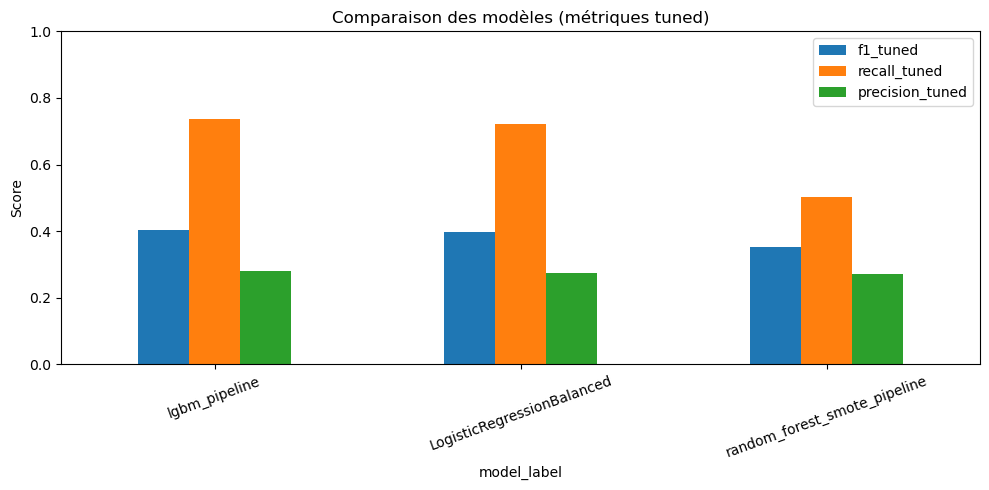

In [17]:
import matplotlib.pyplot as plt

plot_df = results_df[['model_label', 'f1_tuned', 'recall_tuned', 'precision_tuned']].copy()
plot_df = plot_df.set_index('model_label')

ax = plot_df.plot(kind='bar', figsize=(10, 5), rot=20)
ax.set_title('Comparaison des modèles (métriques tuned)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()